In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

import warnings
warnings.filterwarnings("ignore")

import scpositioner as sp
from scpositioner.tl import HighResMapper

In [2]:
# demo data can be downloaded via https://drive.google.com/drive/folders/1TeTbrlNB62c7hIUEp4D8eDTSZKRS3C63?usp=sharing
sc_adata = sc.read('sc_BC.h5ad')
st_adata = sc.read('st_BC.h5ad')

In [3]:
sc_adata

AnnData object with n_obs × n_vars = 26031 × 18082
    obs: 'Annotation'
    var: 'gene_ids', 'feature_types', 'genome'

In [4]:
st_adata

AnnData object with n_obs × n_vars = 158030 × 313
    obs: 'Barcode', 'Cluster', 'Cell', 'x', 'y', 'Cluster2'
    var: 'Ensembl', 'Name', 'Type'
    uns: 'Cluster2_colors', 'Cluster_colors'
    obsm: 'spatial'

In [5]:
mapper = HighResMapper(
            S = sc_adata,
            R = st_adata,
            S_celltype_key = 'Annotation',
            R_celltype_key = 'Cluster2',
            normalize = True,
            numItermax = 1e6,
            seed = 0)

In [6]:
adata_new = mapper.run()

[2026-03-28 09:36:41] Checking single cell AnnData: 26031 cells * 18082 features, 17 cell types.
[2026-03-28 09:36:41] Checking spatial reference AnnData: 158030 cells * 313 features; 17 cell types.
[2026-03-28 09:36:41] 17 common cell types found between single cell and spatial reference AnnData.
[2026-03-28 09:36:41] 10 cores are used.
[2026-03-28 09:36:41] Filtering features and cells...
[2026-03-28 09:36:43] Adjusting cell aboundance in single cell AnnData...
[2026-03-28 09:36:43] Adjusting cell aboundance in single cell AnnData...
[2026-03-28 09:36:43] Adjusting cell aboundance in single cell AnnData...
[2026-03-28 09:36:43] Adjusting cell aboundance in single cell AnnData...
[2026-03-28 09:36:43] Adjusting cell aboundance in single cell AnnData...
[2026-03-28 09:36:43] Adjusting cell aboundance in single cell AnnData...
[2026-03-28 09:36:43] Adjusting cell aboundance in single cell AnnData...
[2026-03-28 09:36:43] Adjusting cell aboundance in single cell AnnData...
[2026-03-28 09

RESULT MIGHT BE INACURATE
Max number of iteration reached, currently 1000000. Sometimes iterations go on in cycle even though the solution has been reached, to check if it's the case here have a look at the minimal reduced cost. If it is very close to machine precision, you might actually have the correct solution, if not try setting the maximum number of iterations a bit higher
RESULT MIGHT BE INACURATE
Max number of iteration reached, currently 1000000. Sometimes iterations go on in cycle even though the solution has been reached, to check if it's the case here have a look at the minimal reduced cost. If it is very close to machine precision, you might actually have the correct solution, if not try setting the maximum number of iterations a bit higher


[2026-03-28 09:39:05] Assigning cells...
[2026-03-28 09:39:27] Creating new AnnData object...
[2026-03-28 09:39:31] Assigning cells...
[2026-03-28 09:40:04] Creating new AnnData object...
[2026-03-28 09:40:14] Done!


In [7]:
adata_new

AnnData object with n_obs × n_vars = 158030 × 17664
    obs: 'CellID_new', 'CellID_original', 'CellType', 'SpotID', 'X', 'Y', 'X_jitter', 'Y_jitter'
    obsm: 'spatial_raw', 'spatial'

In [8]:
adata_new.write('BC_mapped.h5ad')

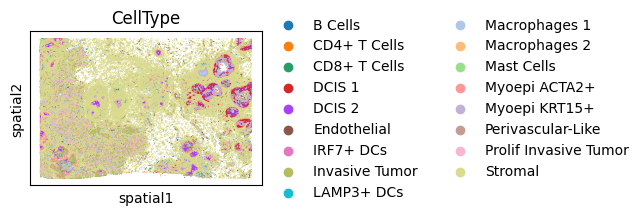

In [9]:
plt.rcParams["figure.figsize"] = (3, 2)
sc.pl.embedding(adata_new, basis='spatial', s=2, color=['CellType'])

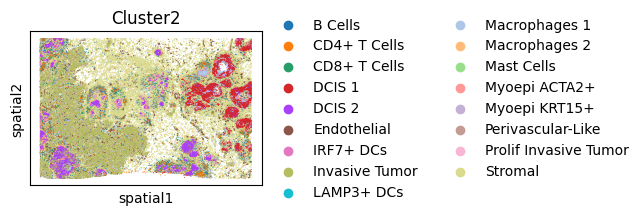

In [10]:
plt.rcParams["figure.figsize"] = (3, 2)
sc.pl.embedding(st_adata, basis='spatial', s=2, color=['Cluster2'])